In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [ ]:
cohort = pd.read_csv("/data/processed/cohort_data.csv")

In [3]:
cohort.head()

,cohort_month,cohort_index,customers
0,2016-09-01 00:00:00,0,4
1,2016-10-01 00:00:00,0,321
2,2016-10-01 00:00:00,6,1
3,2016-10-01 00:00:00,9,1
4,2016-10-01 00:00:00,11,1


In [4]:
cohort.info()

<class 'pandas.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cohort_month  225 non-null    str  
 1   cohort_index  225 non-null    int64
 2   customers     225 non-null    int64
dtypes: int64(2), str(1)
memory usage: 9.6 KB


In [5]:
cohort.isnull().sum()

cohort_month    0
cohort_index    0
customers       0
dtype: int64

In [6]:
cohort["cohort_month"] = pd.to_datetime(cohort["cohort_month"])

In [7]:
cohort.dtypes

cohort_month    datetime64[us]
cohort_index             int64
customers                int64
dtype: object

In [8]:
cohort_table = cohort.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="customers"
)

cohort_table

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09-01,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,321.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12-01,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,764.0,3.0,2.0,1.0,3.0,1.0,4.0,1.0,1.0,NaN,3.0,1.0,6.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02-01,1752.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,3.0,4.0,2.0,5.0,3.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN
2017-03-01,2636.0,13.0,10.0,10.0,9.0,4.0,4.0,8.0,9.0,2.0,10.0,4.0,6.0,3.0,4.0,6.0,2.0,4.0,NaN,NaN
2017-04-01,2352.0,14.0,5.0,4.0,8.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,2.0,1.0,2.0,2.0,5.0,NaN,NaN,NaN
2017-05-01,3596.0,18.0,18.0,14.0,11.0,12.0,15.0,6.0,9.0,11.0,9.0,12.0,9.0,1.0,7.0,9.0,NaN,NaN,NaN,NaN
2017-06-01,3139.0,15.0,11.0,13.0,8.0,12.0,12.0,7.0,4.0,7.0,10.0,11.0,5.0,4.0,6.0,NaN,NaN,NaN,NaN,NaN


In [9]:
retention = cohort_table.divide(
    cohort_table[0],
    axis=0
)

In [10]:
retention = retention * 100

In [11]:
retention = retention.round(1)

In [12]:
retention

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09-01,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,100.0,NaN,NaN,NaN,NaN,NaN,0.3,NaN,NaN,0.3,NaN,0.3,NaN,0.3,NaN,0.3,NaN,0.3,0.6,0.6
2016-12-01,100.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,100.0,0.4,0.3,0.1,0.4,0.1,0.5,0.1,0.1,NaN,0.4,0.1,0.8,0.4,0.1,0.1,0.3,0.4,0.1,NaN
2017-02-01,100.0,0.2,0.3,0.1,0.4,0.1,0.2,0.2,0.2,0.2,0.1,0.3,0.2,0.2,0.1,0.1,0.1,0.2,NaN,NaN
2017-03-01,100.0,0.5,0.4,0.4,0.3,0.2,0.2,0.3,0.3,0.1,0.4,0.2,0.2,0.1,0.2,0.2,0.1,0.2,NaN,NaN
2017-04-01,100.0,0.6,0.2,0.2,0.3,0.3,0.3,0.3,0.3,0.2,0.3,0.1,0.1,0.0,0.1,0.1,0.2,NaN,NaN,NaN
2017-05-01,100.0,0.5,0.5,0.4,0.3,0.3,0.4,0.2,0.3,0.3,0.3,0.3,0.3,0.0,0.2,0.3,NaN,NaN,NaN,NaN
2017-06-01,100.0,0.5,0.4,0.4,0.3,0.4,0.4,0.2,0.1,0.2,0.3,0.4,0.2,0.1,0.2,NaN,NaN,NaN,NaN,NaN


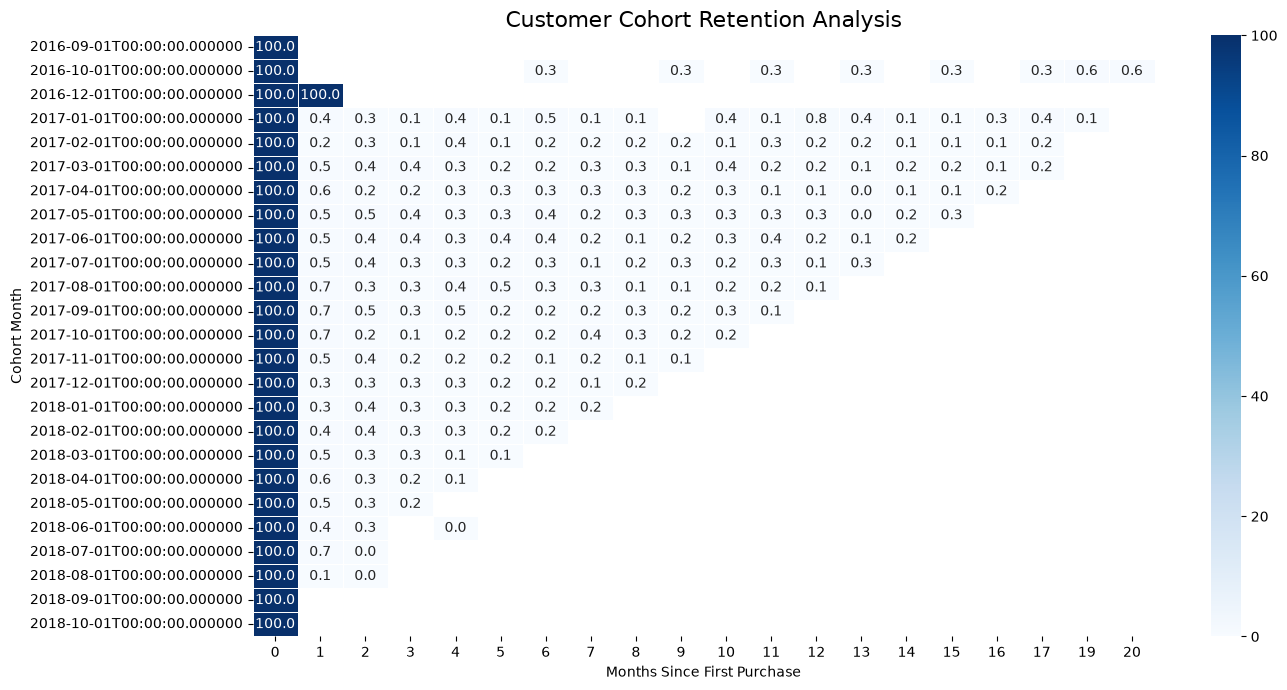

In [14]:
plt.figure(figsize=(14,7))

sns.heatmap(
    retention,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Customer Cohort Retention Analysis", fontsize=16)
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.tight_layout()

plt.savefig("../images/cohort_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
retention.to_csv("/data/processed/cohort_retention.csv")